In [1]:
from autoenkoop import *
import torch
from torch.utils.data import DataLoader
import numpy as np
from numpy.linalg import svd, eig
import pandas as pd
import os
import pydmd
from pydmd.plotter import plot_summary
from tqdm import tqdm
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

DEVICE = "cuda"

In [2]:
data_path = os.path.join("..", "data", "T1492_x1151_y1_z127_c2.npz")
center_dataset = True
train_test_split = 0.7
train_data, test_data, temp_mean = load_and_prepare_data(data_path, center_dataset, train_test_split)

In [3]:
full_data = np.concatenate((train_data, test_data), axis=0)

original_data = full_data + temp_mean
temp_mean_error = np.mean((full_data - temp_mean)**2, axis=(1,2,3))

In [13]:
(vx_min, vx_max), (vz_min, vz_max) = get_min_max(original_data)
vx_absmax = max(abs(vx_min), abs(vx_max))*0.7
vz_absmax = max(abs(vz_min), abs(vz_max))*0.7
norm_x = Normalize(vmin=-vx_absmax, vmax=+vx_absmax)
norm_z = Normalize(vmin=-vz_absmax, vmax=+vz_absmax)

In [14]:
full_data.shape

(1493, 2, 1151, 127)

In [6]:
PREDICTION_WINDOW = 100
window_offset_data = full_data[:-PREDICTION_WINDOW]

dataset_full = SimpleDataset(window_offset_data)

loader_full = DataLoader(dataset_full, batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

dataset_train = SimpleDataset(train_data)
loader_train = DataLoader(dataset_train, batch_size=4, shuffle=False)

full_data = np.moveaxis(full_data, -1, 1)

In [7]:
def calculate_koopman(model, loader):
    Z = []
    with torch.no_grad():
        for x_t in loader:
            x_t = x_t.to(DEVICE)
            #encoded current state
            z_t = model.encoder(x_t) 
            Z.append(z_t.cpu().numpy())
    Z_all = np.vstack(Z).T
    dmd = pydmd.DMD(-1, forward_backward=False)
    dmd.fit(Z_all)
    K_star = (dmd.modes @ np.diag(dmd.eigs) @ np.linalg.pinv(dmd.modes)).real
    return K_star

In [8]:
run_name = "L128_dmd_none_batch_batch_nobias_wlin1"

run_path = os.path.join("..", "results", "kae_experiments", run_name)
hyperparam = run_name.split('_')
LATENT_DIM = int(hyperparam[0][1:])
koopman_type = hyperparam[1]
weight_std = hyperparam[2] == "weightstd"
norm_type = hyperparam[3]
norm_latent = hyperparam[4]
use_bias = hyperparam[5] == "bias"

model = ConvAutoencoder(latent_dim=LATENT_DIM, weight_standard=weight_std, bias_terms=use_bias, norm_type=norm_type, norm_latent=norm_latent).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(run_path, "model.pt"), map_location=DEVICE))
model.eval()
K = torch.tensor(calculate_koopman(model, loader_train), device=DEVICE, requires_grad=False)

In [13]:
temp_mean_new = np.permute_dims(temp_mean, (2,0,1))

In [8]:
predictor, _ = get_multi_step_predictor_K(K=K)

In [8]:
#with torch.no_grad():
#    for j, x_t in tqdm(enumerate(loader_full), total=len(dataset_full)):
#        x_t = x_t.to(DEVICE)
#        z_t = model.encoder(x_t).squeeze(0)
#        z_trajectory = predictor(z_t, PREDICTION_WINDOW)
#        X_prediction = model.decoder(z_trajectory).cpu().numpy()
#        X_prediction_wmean = (X_prediction + temp_mean_new).astype(np.float16)        
#        np.save(os.path.join(run_path, "all_predictions", str(j)), X_prediction_wmean)

In [9]:
original_vx = original_data[700:801, 600, :, :]
original_profile = np.mean(original_vx, 0)#np.mean(original_vx**2, 0) - np.mean(original_vx, 0)**2

In [89]:
index = 700
x_coord = 600
profiles = np.zeros((101, 2, 127))
for t in tqdm(range(101), total=101):
    all_vx = np.zeros((101, 2, 127))
    for i in range(101):
        prediction_window = np.load(os.path.join(run_path, "all_predictions", str(index+i-t)+".npy"))
        all_vx[i] = prediction_window[t, :, x_coord, :]

    profiles[t] = np.mean(all_vx, 0)#np.mean(all_vx**2, 0) - np.mean(all_vx, 0)**2

100%|██████████| 101/101 [03:36<00:00,  2.14s/it]


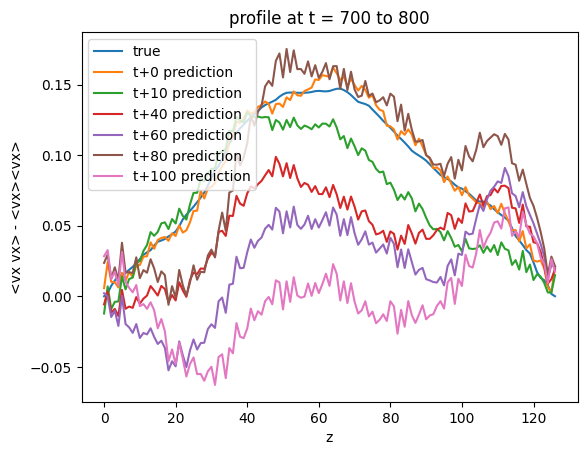

In [94]:
component = 1

plot_evolution([original_profile.T[component], profiles[0][component], profiles[10][component], profiles[40][component], profiles[60][component], profiles[80][component], profiles[100][component]], ["true", f"t+{0} prediction", f"t+{10} prediction", f"t+{40} prediction", f"t+{60} prediction", f"t+{80} prediction", f"t+{100} prediction"], title="profile at t = 700 to 800", xlabel="z", ylabel="<vx vx> - <vx><vx>")
plt.yscale("linear")

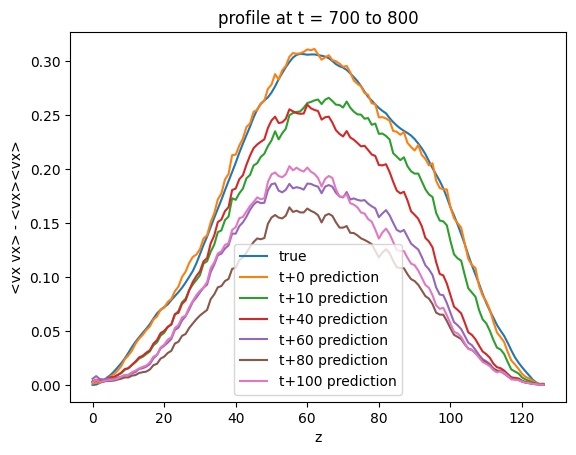

In [83]:
component = 1

plot_evolution([original_profile.T[component], profiles[0][component], profiles[10][component], profiles[40][component], profiles[60][component], profiles[80][component], profiles[100][component]], ["true", f"t+{0} prediction", f"t+{10} prediction", f"t+{40} prediction", f"t+{60} prediction", f"t+{80} prediction", f"t+{100} prediction"], title="profile at t = 700 to 800", xlabel="z", ylabel="<vx vx> - <vx><vx>")
plt.yscale("linear")

In [17]:
temp_mean.shape

(1151, 127, 2)

In [18]:
vx, vz = temp_mean[:,:,0], temp_mean[:,:,1]

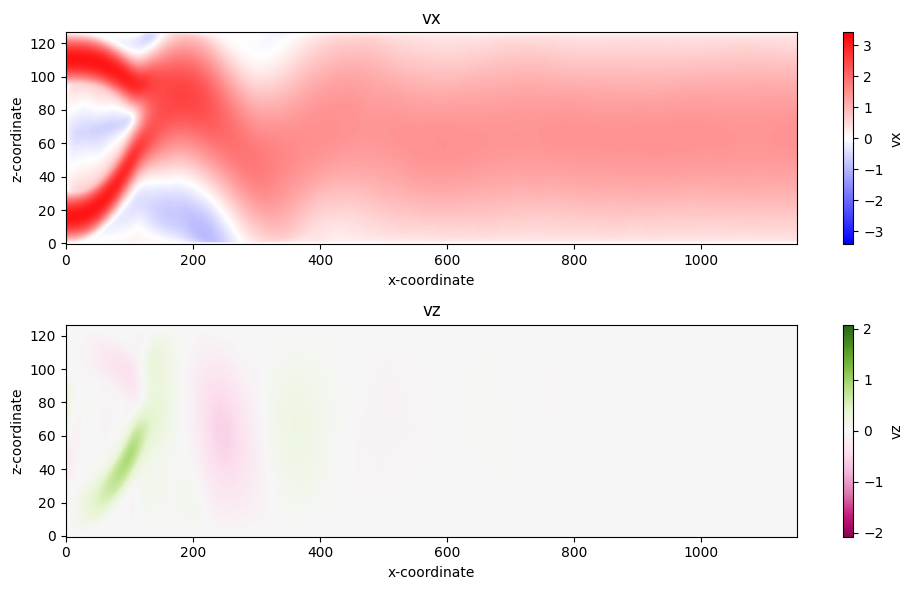

In [19]:
plot_vx_vz(vx, vz, norm_x, norm_z)
plt.savefig("snapshot.png", dpi=300)

In [74]:
test_data = np.load(os.path.join("..", "data", "extractionTest.npz"))

In [ ]:
test_data['timeseries']

np.float32(0.0)

In [10]:
prediction_200 = np.load(os.path.join(run_path, "all_predictions", "200.npy"))

In [11]:
prediction_200.shape

(101, 2, 1151, 127)

In [12]:
original_200 = original_data[200:301]
print(original_200.shape)

(101, 1151, 127, 2)


In [33]:
time_stamp = 0

vx_o, vz_o = original_200[time_stamp, :, :, 0], original_200[time_stamp, :, :, 1]
vx_p, vz_p = prediction_200[time_stamp, 0, :, :], prediction_200[time_stamp, 1, :, :]

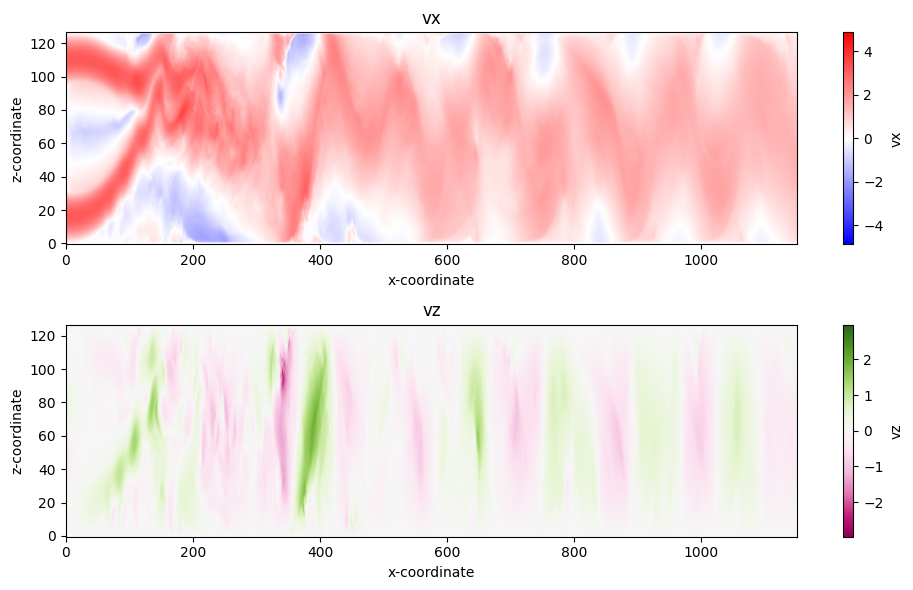

In [28]:
plot_vx_vz(vx_o, vz_o, norm_x, norm_z)
plt.savefig("original240.png")

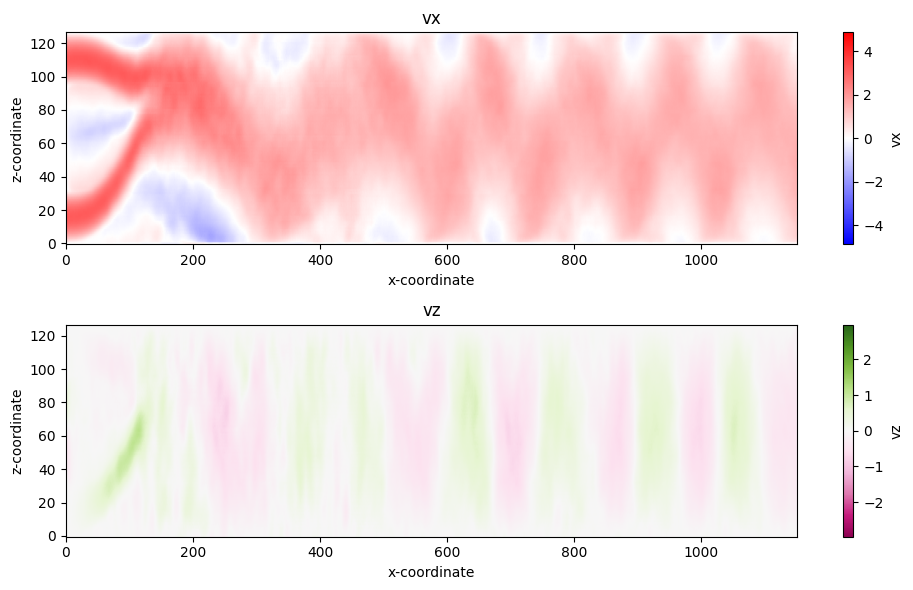

In [29]:
plot_vx_vz(vx_p, vz_p, norm_x, norm_z)
plt.savefig("pred240_40.png")

In [34]:
vx_diff, vz_diff = vx_o - vx_p, vz_o - vz_p

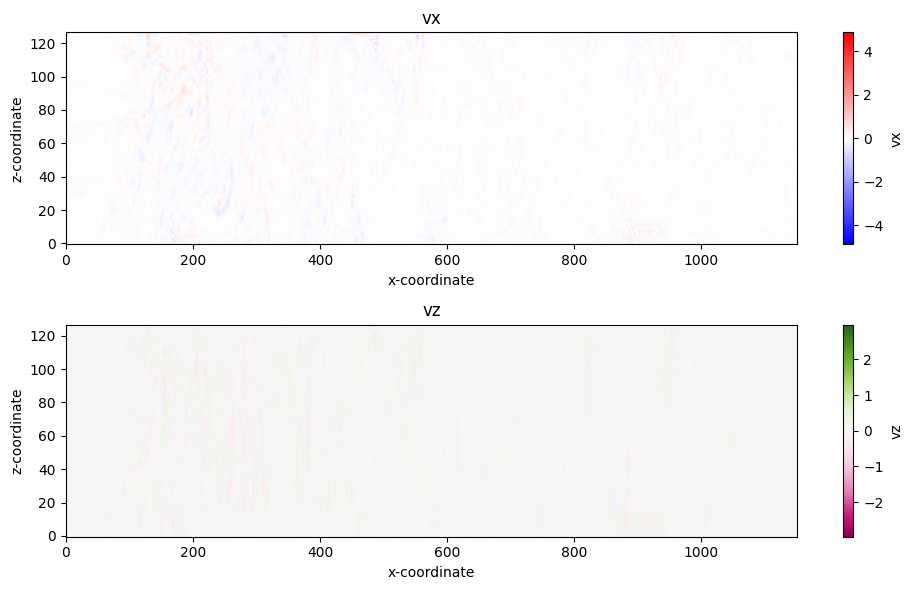

In [35]:
plot_vx_vz(vx_diff, vz_diff, norm_x, norm_z)
plt.savefig("err_0")

In [36]:
prediction_400 = np.load(os.path.join(run_path, "all_predictions", "400.npy"))

In [100]:
def angle_between_vectors(A, B):
    
    dot_product = np.dot(A, B)
    
    # Calculate magnitudes (lengths of the vectors)
    magnitude_A = np.linalg.norm(A)
    magnitude_B = np.linalg.norm(B)
    
    # Calculate angle in radians
    angle_radians = np.arccos(dot_product / (magnitude_A * magnitude_B))
    
    # Convert radians to degrees
    return angle_radians

In [147]:

xcoords = []
ycoords = []

radians_sum = 0
for i in range(200, 1200):
    first = full_data[i].flatten()
    second = full_data[i+1].flatten()
    radians_sum += angle_between_vectors(first, second)
    #print(radians_sum)
    radius = np.mean(first**2)
    #print(radius)
    xcoords.append(radius*np.cos(radians_sum))
    ycoords.append(radius*np.sin(radians_sum))

In [148]:
radius

np.float64(0.2446626495873609)

In [149]:
import matplotlib

cmap = matplotlib.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 1200-200))

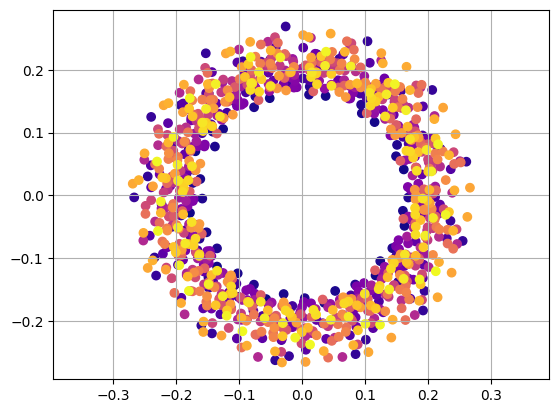

In [152]:
plt.scatter(xcoords, ycoords, c=colors)
plt.axis('equal')
plt.grid()
plt.savefig("tke_shell.png")

In [ ]:
np.mean(prediction_400[0, 0, :, :], axis=1)

(1151,)

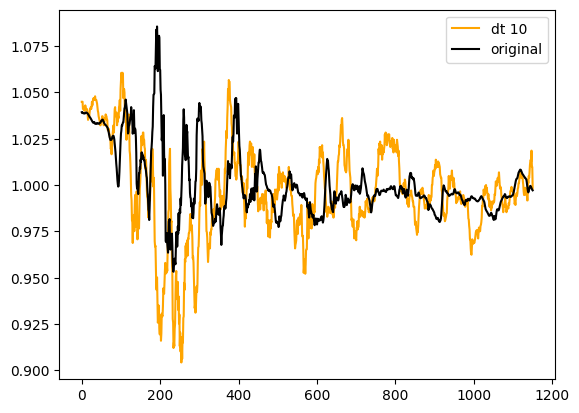

In [74]:
#plt.plot(np.mean(prediction_400[0, 0, :, :], axis=1), label="dt 0", c="green")
plt.plot(np.mean(prediction_400[10, 0, :, :], axis=1), label="dt 10", c="orange")
#plt.plot(np.mean(prediction_400[40, 0, :, :], axis=1), label="dt 40", c="purple")
plt.plot(np.mean(original_data[400], 1)[:,0], label="original", c="black")
plt.legend()
plt.savefig("massconservation_dt10.png")

In [39]:
G = np.mean(temp_mean[:, :, 0], axis=1)

In [ ]:
dt0_list_outlet = []
dt10_list_outlet = []
dt40_list_outlet = []
for i in tqdm(range(1200)):
    predictions = np.load(os.path.join(run_path, "all_predictions", str(i)+".npy"))       
    dt0_list_outlet.append(np.mean(predictions[0, 0, -1, :], axis=0))
    dt10_list_outlet.append(np.mean(predictions[10, 0, -1, :], axis=0))
    dt40_list_outlet.append(np.mean(predictions[40, 0, -1, :], axis=0))

100%|██████████| 1200/1200 [00:52<00:00, 23.02it/s]


In [58]:
dt0_ary_outlet = np.array(dt0_list_outlet)
dt10_ary_outlet = np.array(dt10_list_outlet)
dt40_ary_outlet = np.array(dt40_list_outlet)

In [59]:
outlet = np.mean(original_data[:1200, -1, :, 0], axis=1)

In [77]:
def window_mean(array, window_size=20):
    return np.mean(np.lib.stride_tricks.sliding_window_view(array, window_shape=window_size), axis=1)

In [78]:
wm_original_outlet = window_mean(outlet)
wm_dt0_outlet = window_mean(dt0_ary_outlet)
wm_dt10_outlet = window_mean(dt10_ary_outlet)
wm_dt40_outlet = window_mean(dt40_ary_outlet)

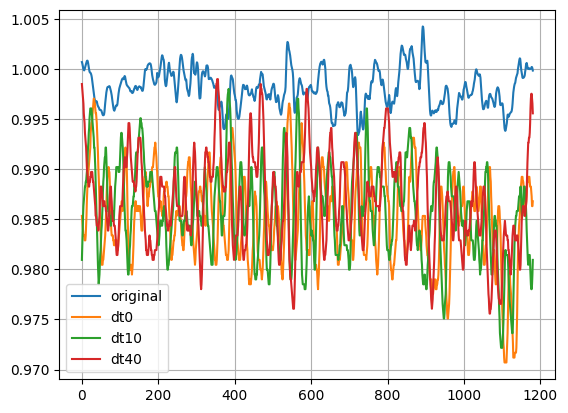

In [82]:
plt.plot(wm_original_outlet, label="original")
plt.plot(wm_dt0_outlet, label="dt0")
plt.plot(wm_dt10_outlet, label="dt10")
plt.plot(wm_dt40_outlet, label="dt40")
plt.grid()
plt.legend()
plt.savefig("outlet_streamwise_flux.png")

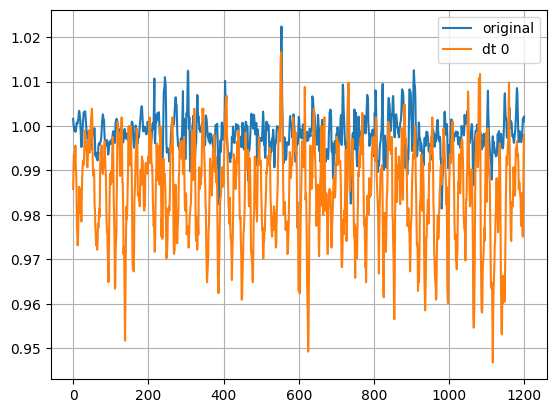

In [61]:
plt.plot(outlet, label="original")
plt.plot(dt0_ary_outlet, label="dt 0")
#plt.plot(dt10_ary_outlet, label="dt 10")
#plt.plot(dt40_ary_outlet, label="dt 40")
plt.grid()
plt.legend()

In [ ]:
full_data

(1493, 2, 1151, 127)

In [43]:
G

array([1.03927011, 1.03865127, 1.03815022, ..., 0.99818644, 0.99815555,
       0.99815931], shape=(1151,))

In [10]:
def tke_calc(data_slice):
    return 0.5*np.sum(np.mean(data_slice[:1200]**2, axis=(1,2)) - np.mean(data_slice[:1200], axis=(1,2))**2, 1)
TKE = tke_calc(original_data)

In [26]:
def tke_calc(data_slice):
    return np.mean(data_slice[:1200]**2, axis=(1,2)) - np.mean(data_slice[:1200], axis=(1,2))**2
TKE = tke_calc(original_data)

In [34]:
single_point_trajectory = full_data[:1200, 1000, 63]

In [35]:
single_point_trajectory.shape

(1200, 2)

In [ ]:


# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, 1200))

In [38]:
dmd_model = pydmd.DMD(svd_rank=2)

In [ ]:
dmd_model.fit()

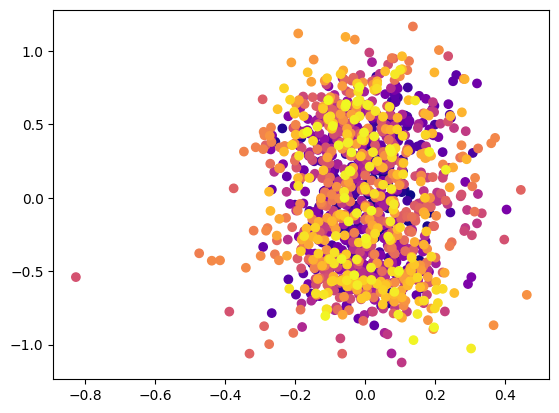

In [37]:
plt.scatter(single_point_trajectory[:, 0], single_point_trajectory[:, 1], c=colors)
#plt.ylim(0, 0.25)
#plt.xlim(0, 0.75)

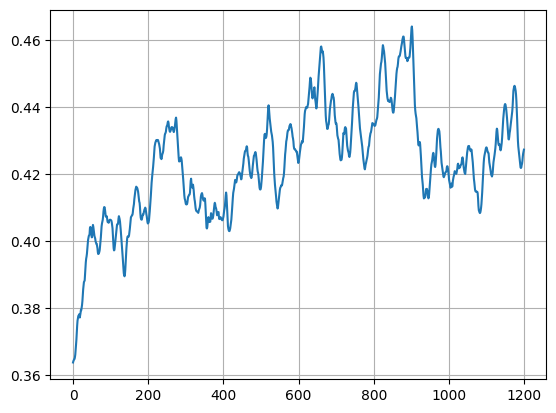

In [124]:
plt.plot(TKE)
plt.grid()
plt.savefig("tke_original.png")

In [111]:
np.mean(prediction_400, axis=(2,3)).shape

(101, 2)

In [125]:
prediction_640 = np.load(os.path.join(run_path, "all_predictions", "640.npy"))

In [126]:
TKE_pred640 = 0.5*np.sum(np.mean(prediction_640**2, axis=(2,3)) - np.mean(prediction_640, axis=(2,3))**2, 1)

In [117]:
TKE_pred400.shape

(101,)

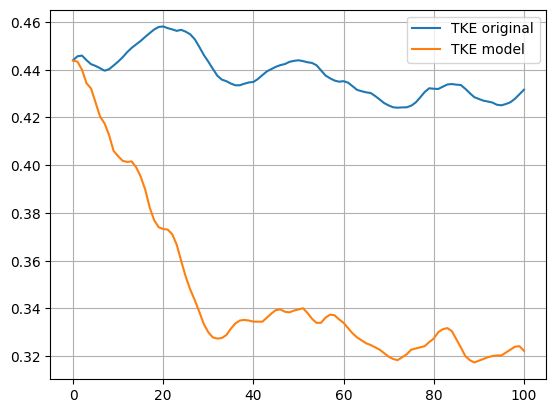

In [127]:
plt.plot(TKE[640:741], label="TKE original")
plt.plot(TKE_pred640, label="TKE model")
plt.grid()
plt.legend()
plt.savefig("tke_ts640.png")

In [134]:
original_data[300,:,63,1].shape

(1151,)

In [18]:
original_data.shape

(1493, 1151, 127, 2)

In [33]:
fft_freq = np.fft.fftfreq(1151-500, 25/1151)
idx = np.argsort(fft_freq)
fft_powers_list = []
for t in tqdm(range(1200), total=1200):
    v_component = original_data[t,500:,63,1]
    fft_data = np.fft.fft(v_component)
    fft_powers = np.abs(fft_data)**2
    fft_powers_list.append(fft_powers)
fft_powers_arr = np.array(fft_powers_list)

100%|██████████| 1200/1200 [00:00<00:00, 8310.76it/s]


In [34]:
fft_powers_arr

array([[1.11683311e+02, 2.88117877e+02, 2.00266518e+02, ...,
        3.45324679e+03, 2.00266518e+02, 2.88117877e+02],
       [6.17692867e+01, 1.90495254e+02, 1.86575392e+02, ...,
        3.08967560e+03, 1.86575392e+02, 1.90495254e+02],
       [3.26608423e+01, 1.20566454e+02, 1.78949098e+02, ...,
        2.79445795e+03, 1.78949098e+02, 1.20566454e+02],
       ...,
       [5.02145414e-03, 1.15428499e+01, 3.41816427e+02, ...,
        3.00984026e+03, 3.41816427e+02, 1.15428499e+01],
       [4.65319999e+01, 8.15972396e+01, 4.80004451e+02, ...,
        3.10030209e+03, 4.80004451e+02, 8.15972396e+01],
       [2.39319661e+02, 2.79793960e+02, 8.37840309e+02, ...,
        3.32460015e+03, 8.37840309e+02, 2.79793960e+02]],
      shape=(1200, 651))

(0.0, 4.0)

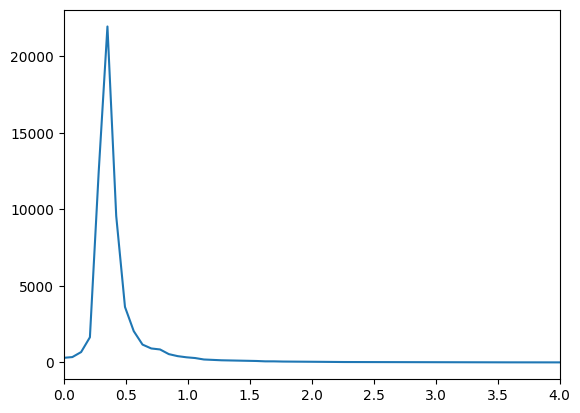

In [35]:
idx = np.argsort(fft_freq)

plt.plot(fft_freq[idx], np.mean(fft_powers_arr, 0)[idx])
plt.xlim(0, 4)

In [30]:
v_component = original_data[0,500:,63,1]

In [32]:
np.mean(v_component)

np.float64(-0.016233536886901077)

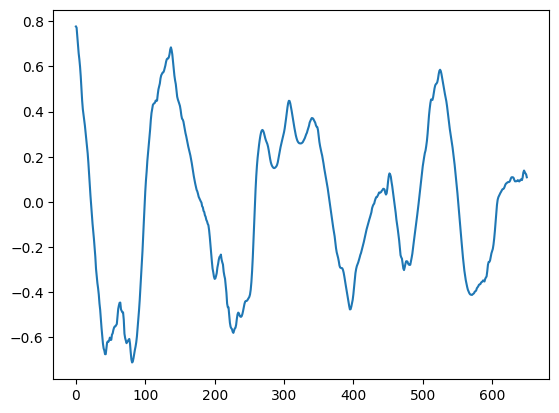

In [31]:
plt.plot(v_component)

In [189]:
70/25

2.8

In [36]:
dt_power_list = []
for dt in [0, 10, 40, 100]:
    fft_powers_list = []
    for i in tqdm(range(1100), total=1100):
        prediction_window = np.load(os.path.join(run_path, "all_predictions", str(i)+".npy"))
        v_component_pred = prediction_window[dt, 1, 500:, 63]
        fft_data = np.fft.fft(v_component_pred)
        fft_powers = np.abs(fft_data)**2
        fft_powers_list.append(fft_powers)
    dt_power_list.append(np.array(fft_powers_list))

100%|██████████| 1100/1100 [01:03<00:00, 17.33it/s]


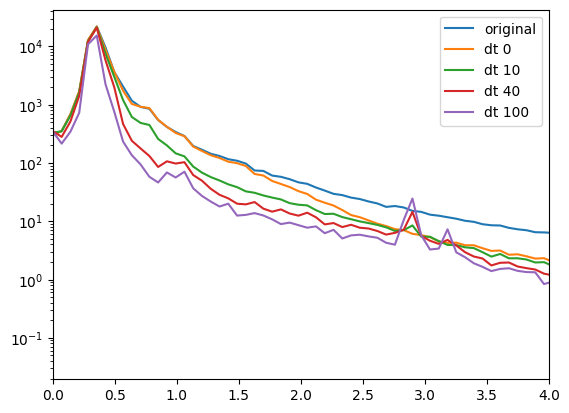

In [37]:
plt.plot(fft_freq[idx], np.mean(fft_powers_arr, 0)[idx], label="original")
plt.plot(fft_freq[idx], np.mean(dt_power_list[0], 0)[idx], label="dt 0")
plt.plot(fft_freq[idx], np.mean(dt_power_list[1], 0)[idx], label="dt 10")
plt.plot(fft_freq[idx], np.mean(dt_power_list[2], 0)[idx], label="dt 40")
plt.plot(fft_freq[idx], np.mean(dt_power_list[3], 0)[idx], label="dt 100")
plt.legend()
plt.xlim(0, 4)
plt.yscale("log")
plt.savefig("f_rolls_x400.png")

In [7]:
fft_freq = np.fft.fftfreq(1160, 480/1200)
idx = np.argsort(fft_freq)
fft_powers_list = []
for x in range(300, 900, 2):
    for z in range(40, 90, 1):
        fft_data = np.fft.fft(original_data[40:1200, x, z, 1])
        fft_powers = np.abs(fft_data)**2
        fft_powers_list.append(fft_powers)

In [8]:
fft_powers_arr = np.array(fft_powers_list)

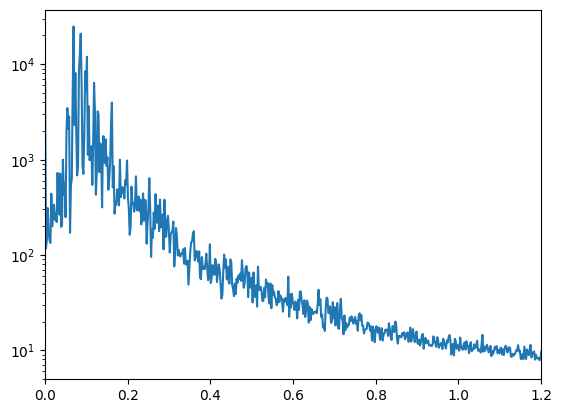

In [9]:
plt.plot(fft_freq[idx], np.mean(fft_powers_arr, 0)[idx], label="original")
plt.xlim(0, 1.2)
plt.yscale("log")

In [12]:
fft_dt_powers_list = []
for dt in [0, 10, 40]:
    pred_list = []
    for t in tqdm(range(40, 1200), total=1200-40):
        prediction_window = np.load(os.path.join(run_path, "all_predictions", str(t-dt)+".npy"))
        #print(prediction_window[0].shape)
        data = prediction_window[dt, 1, 300:900:2, 40:90]
        pred_list.append(data)
        #print(fft_data.shape)
    #        fft_powers = np.abs(fft_data)**2
    #        fft_powers_list.append(fft_powers)
    pred_array = np.array(pred_list)
    pred_list = None
    fft_powers_list = []
    for x in range(pred_array.shape[1]):
        for z in range(pred_array.shape[2]):
            fft_data = np.fft.fft(pred_array[:, x, z])
            fft_power = np.abs(fft_data)**2
            fft_powers_list.append(fft_power)
    fft_dt_powers_list.append(np.mean(np.array(fft_powers_list), 0))

100%|██████████| 1160/1160 [01:50<00:00, 10.48it/s]


In [35]:
from matplotlib import patches

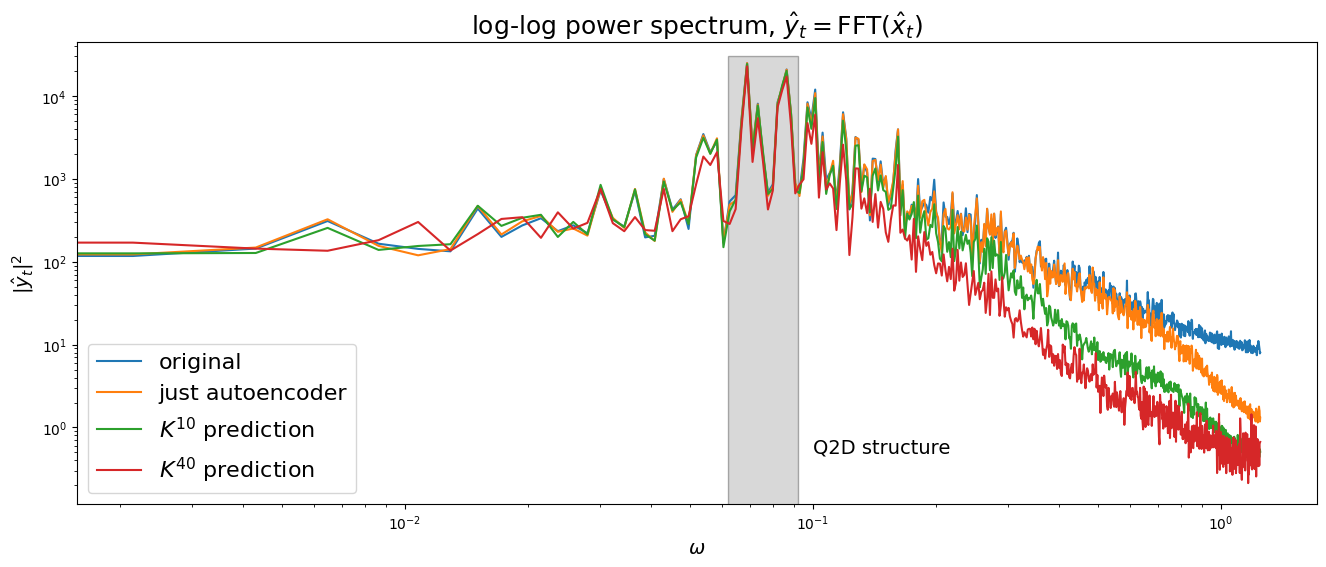

In [130]:
plt.figure(figsize=(16,6))
plt.plot(fft_freq[idx], np.mean(fft_powers_arr, 0)[idx], label=r"original")
plt.plot(fft_freq[idx], fft_dt_powers_list[0][idx], label=r"just autoencoder")
plt.plot(fft_freq[idx], fft_dt_powers_list[1][idx], label=r"$K^{10}$ prediction")
plt.plot(fft_freq[idx], fft_dt_powers_list[2][idx], label=r"$K^{40}$ prediction")
#plt.xlim(0, 1.2)
plt.yscale("log")
plt.xscale("log")
rect = patches.Rectangle((0.062,0), 0.03, 30000, linewidth=1, edgecolor='black', facecolor='gray', alpha=0.3)
plt.gca().add_patch(rect)
plt.text(0.10, 0.5, "Q2D structure", fontsize=14, horizontalalignment="left")
plt.xlabel(r"$\omega$", fontsize=14)
plt.ylabel(r"$|\hat{y}_t|^2$", fontsize=14)
plt.title(r"log-log power spectrum, $\hat{y}_t = \text{FFT}(\hat{x}_t)$", fontsize=18)
plt.legend(loc="lower left", fontsize=16)
plt.savefig("fft_frequency_3.png", dpi=300)

In [20]:
def animate_trajectory(trajectory, file_name, norm_x, norm_z):
    n_timesteps = len(trajectory)
    fig, axes = plt.subplots(2, 1, figsize=(16, 6), dpi=100)
    fig.suptitle(r"Two velocity components at $t = $"+str(0), fontsize=18)
    axes[0].set_aspect("equal")
    axes[1].set_aspect("equal")
    # Initialize first frame
    vx = trajectory[0][0,:]
    vz = trajectory[0][1,:]
    #plt.title(r"$t = 0$")
    im_vx = axes[0].imshow(vx.T, origin='lower', aspect='equal', cmap='bwr', norm=norm_x)
    axes[0].set_title(r"$v_x$", fontsize=16)
    axes[0].set_xlabel("x-index", fontsize=12)
    axes[0].set_ylabel("z-index", fontsize=12)
    #fig.colorbar(im_vx, ax=axes[0], label=r"$v_x$")

    im_vz = axes[1].imshow(vz.T, origin='lower', aspect='equal', cmap='PiYG', norm=norm_z)
    axes[1].set_title(r"$v_z$", fontsize=16)
    axes[1].set_xlabel("x-index", fontsize=12)
    axes[1].set_ylabel("z-index", fontsize=12)
    #fig.colorbar(im_vz, ax=axes[1], label=r"$v_z$")

    plt.tight_layout()

    def update(frame):
        print(frame)
        fig.suptitle(r"Two velocity components at $t = $"+str(frame), fontsize=18)
        vx = trajectory[frame][0,:]
        vz = trajectory[frame][1,:]

        im_vx.set_data(vx.T)
        im_vx.set(norm=norm_x)
        im_vz.set_data(vz.T)
        im_vz.set(norm=norm_z)

        #axes[0].set_title(f"vx at time frame {frame}")
        #axes[1].set_title(f"vz")

        return [im_vx, im_vz]

    ani = FuncAnimation(fig, update,
                        frames=range(n_timesteps),
                        interval=30,
                        blit=False)

    # Save as GIF (requires Pillow)
    writer = PillowWriter(fps=20)
    ani.save(file_name+".gif", writer=writer, dpi=100)

In [21]:
prediction_0 = np.load(os.path.join(run_path, "all_predictions", "0.npy"))

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
0


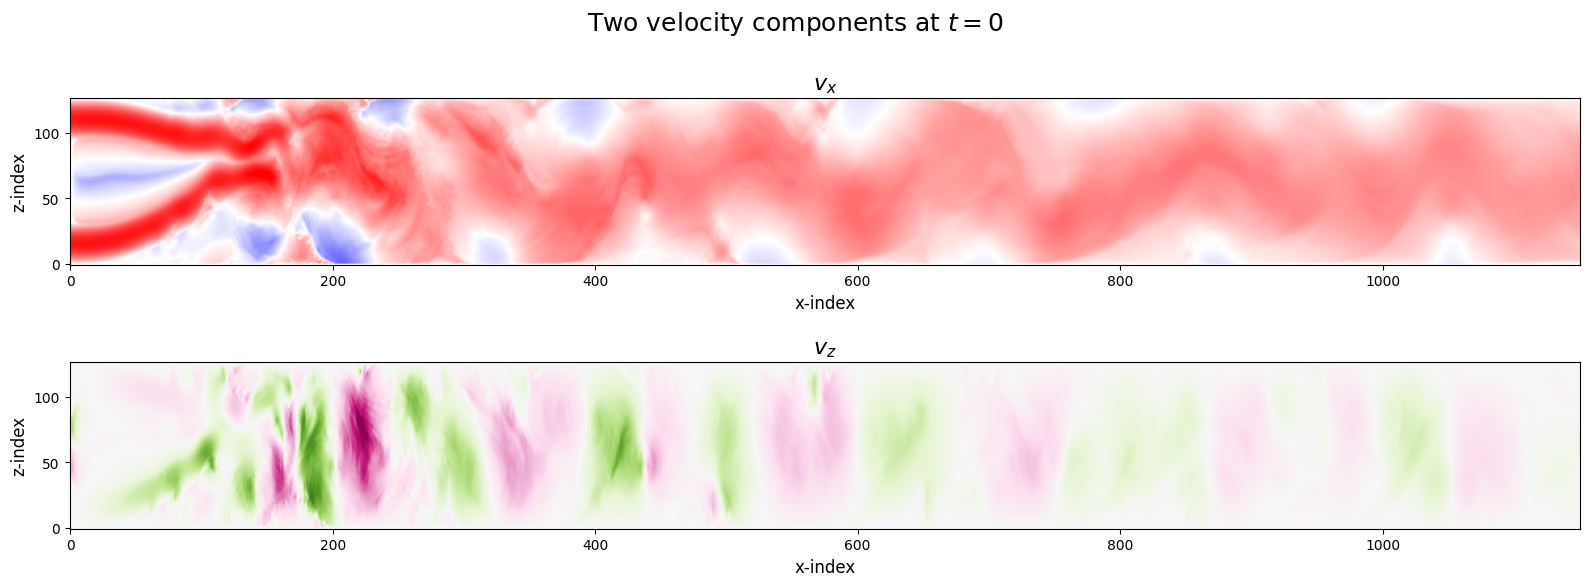

In [22]:
animate_trajectory(np.permute_dims(original_data[:51], (0, 3, 1, 2)), "original0_50_dpi100", norm_x, norm_z)

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
0


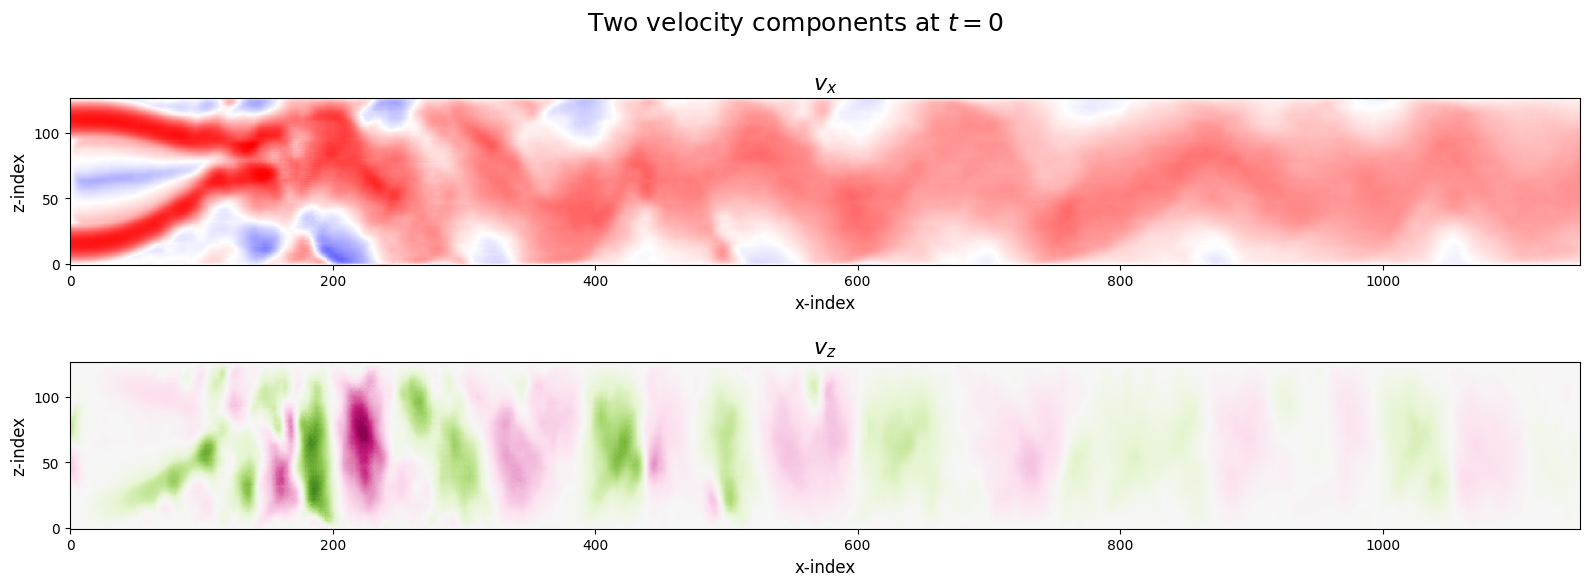

In [23]:
animate_trajectory(prediction_0[:51], "prediction0_50_dpi100", norm_x, norm_z)

In [248]:
def divergence(f):
    """
    Computes the divergence of the vector field f, corresponding to dFx/dx + dFy/dy + ...
    :param f: List of ndarrays, where every item of the list is one dimension of the vector field
    :return: Single ndarray of the same shape as each of the items in f, which corresponds to a scalar field
    """
    num_dims = len(f)
    return np.ufunc.reduce(np.add, [np.gradient(f[i], axis=i) for i in range(num_dims)])

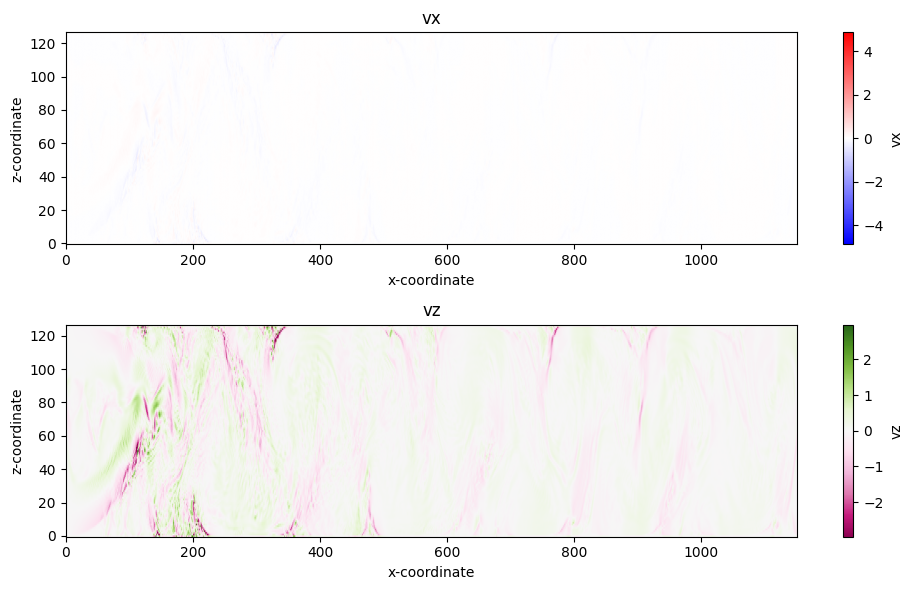

In [251]:
t = 800
div = divergence([original_data[t,:,:,0], original_data[t,:,:,1]])
plot_vx_vz(div, div*10, norm_x, norm_z)

In [ ]:
np.sum(div)

np.float64(-5.1745870419052125)

In [246]:
divergence = dudx+dwdz

In [202]:
divergence_flat = divergence.flatten()

{'whiskers': [<matplotlib.lines.Line2D at 0x231b457d520>,
 'caps': [<matplotlib.lines.Line2D at 0x231b456a960>,
 'boxes': [<matplotlib.lines.Line2D at 0x231b457d460>],
 'medians': [<matplotlib.lines.Line2D at 0x231b47ddc40>],
 'fliers': [<matplotlib.lines.Line2D at 0x231b47de060>],
 'means': []}

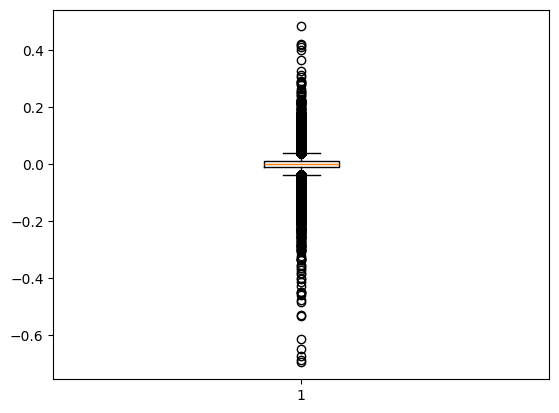

In [203]:
plt.boxplot(divergence_flat)

In [214]:
mask = np.abs(divergence) < 0.01

In [221]:
mask_f32 = mask.astype(np.float32)

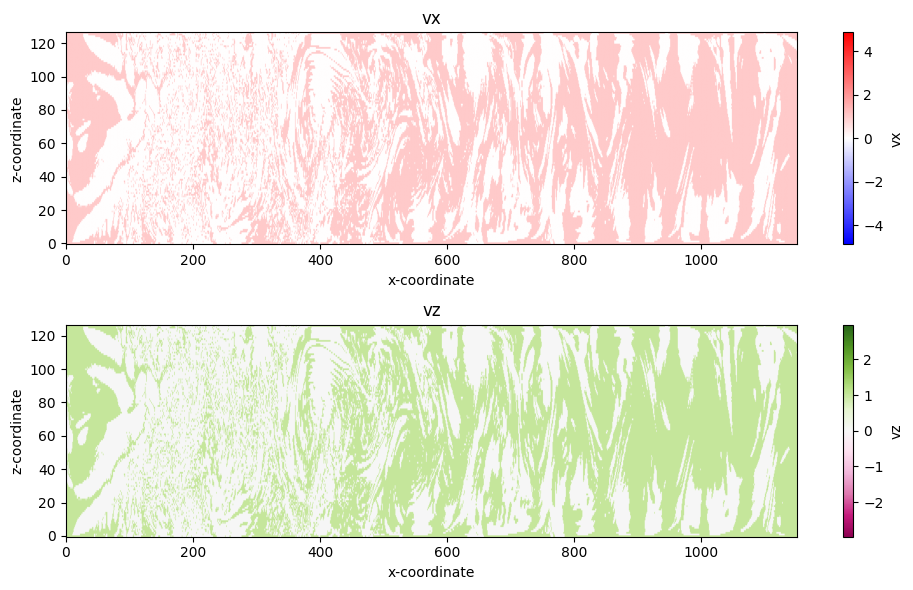

In [223]:
plot_vx_vz(mask_f32, mask_f32, norm_x, norm_z)

In [253]:
prediction_0 = np.load(os.path.join(run_path, "all_predictions", "0.npy"))

In [270]:
all_rMSE = []
for i in tqdm(range(1393)):
    original = np.permute_dims(original_data[i:i+101], (0, 3, 1, 2))
    rMSE = np.mean((original - prediction_0)**2, (1,2,3)) / np.mean(original**2, (1,2,3))
    all_rMSE.append(rMSE)

100%|██████████| 1393/1393 [06:47<00:00,  3.42it/s]


In [271]:
all_rMSE = np.array(all_rMSE)

In [272]:
all_rMSE.shape

(1393, 101)

In [276]:
train_rmse_mean = np.mean(all_rMSE[:1045], axis=0)
test_rmse_mean = np.mean(all_rMSE[1045:], axis=0)

In [277]:
train_rmse_mean.shape

(101,)

In [278]:
train_rmse_mean

array([0.40897686, 0.41670978, 0.41551064, 0.41269103, 0.4053321 ,
       0.39907763, 0.38704264, 0.37790238, 0.37359459, 0.36775056,
       0.36414933, 0.35651101, 0.34586688, 0.3410438 , 0.33745661,
       0.33171471, 0.32828193, 0.32699343, 0.32419686, 0.32003066,
       0.31601505, 0.31165238, 0.30848277, 0.30644195, 0.3045883 ,
       0.30291257, 0.30132258, 0.30028946, 0.30012363, 0.29997308,
       0.2994688 , 0.29892521, 0.29870694, 0.298719  , 0.29884097,
       0.29913131, 0.29949757, 0.29973805, 0.29972478, 0.29913131,
       0.29800996, 0.29656175, 0.29511744, 0.29418176, 0.29375637,
       0.29360758, 0.29331611, 0.29251547, 0.29134425, 0.28994964,
       0.28836186, 0.28675744, 0.28542247, 0.28443417, 0.28377683,
       0.28328841, 0.28289496, 0.28245088, 0.28153487, 0.28009643,
       0.27854393, 0.27742137, 0.27697463, 0.27687394, 0.27660566,
       0.27602217, 0.27535882, 0.27487413, 0.27460179, 0.27440373,
       0.27414947, 0.27374999, 0.27317297, 0.27244531, 0.27162

In [279]:
test_rmse_mean

array([0.39888406, 0.40632556, 0.40522529, 0.40327998, 0.39661207,
       0.39106015, 0.37920631, 0.37018778, 0.36599943, 0.35985251,
       0.35659008, 0.35023673, 0.34095256, 0.33654697, 0.33275713,
       0.32694332, 0.32317723, 0.32165015, 0.31906936, 0.31531633,
       0.31181994, 0.30807084, 0.30545713, 0.30381974, 0.3022754 ,
       0.30072676, 0.29907611, 0.29795836, 0.29775564, 0.29755501,
       0.29720271, 0.29711841, 0.29729415, 0.29741295, 0.29744053,
       0.29751436, 0.29749395, 0.29731995, 0.29708228, 0.29647325,
       0.2955239 , 0.29441399, 0.29337875, 0.29282679, 0.29267836,
       0.29265519, 0.29230213, 0.29136217, 0.29014418, 0.28877546,
       0.28725214, 0.28578257, 0.28462668, 0.28378186, 0.28321856,
       0.28277927, 0.28238484, 0.281873  , 0.2808381 , 0.27928069,
       0.2776279 , 0.27642449, 0.27597521, 0.27595183, 0.27581089,
       0.2753733 , 0.2748567 , 0.27446893, 0.27423494, 0.27406264,
       0.27387756, 0.27360754, 0.27323419, 0.2727504 , 0.27214